In [2]:
import pandas as pd
df = pd.read_csv("cholera_data_jhu.csv")

In [3]:
# Count how many records are real vs ghost
real_count = df['processing_notes'].str.contains("Phantom: False").sum()
ghost_count = df['processing_notes'].str.contains("Phantom: True").sum()

print("Real records:", real_count)
print("Ghost records:", ghost_count)

Real records: 232095
Ghost records: 80


In [5]:
df['delete_flag'] = 0

# Mark ghost records (phantom = True) with 1
df.loc[df['processing_notes'].str.contains("Phantom: True"), 'delete_flag'] = 1

In [9]:
# Now check duplicates among Location + TL + TR
duplicate_mask = df.duplicated(subset=['Location','TL','TR'], keep='first')

# Count how many duplicates exist
duplicate_count = duplicate_mask.sum()

print("Total records:", len(df))
print("Duplicate records (same Location + TL + TR):", duplicate_count)

Total records: 232175
Duplicate records (same Location + TL + TR): 144033


In [10]:
# Extract duplicates into a new DataFrame
duplicates = df[duplicate_mask]

# Save duplicates to a new CSV file
duplicates.to_csv("cholera_duplicates.csv", index=False)

print("Duplicate records saved to cholera_duplicates.csv")
print("Number of duplicates:", len(duplicates))

Duplicate records saved to cholera_duplicates.csv
Number of duplicates: 144033


In [11]:
# Mark duplicates (extra copies beyond the first) with 1
duplicate_mask = df.duplicated(subset=['Location','TL','TR'], keep='first')
df.loc[duplicate_mask, 'delete_flag'] = 1

# Check counts
print("Duplicates marked for deletion:", df['delete_flag'].sum())
print("Remaining real records:", len(df) - df['delete_flag'].sum())

Duplicates marked for deletion: 144053
Remaining real records: 88122


In [12]:
ghost_mask = df['processing_notes'].str.contains("Phantom: True")
duplicate_mask = df.duplicated(subset=['Location','TL','TR'], keep='first')

overlap = (ghost_mask & duplicate_mask).sum()
print("Ghost records:", ghost_mask.sum())
print("Duplicates:", duplicate_mask.sum())
print("Overlap (ghost + duplicate):", overlap)
print("Total flagged:", df['delete_flag'].sum())

Ghost records: 80
Duplicates: 144033
Overlap (ghost + duplicate): 60
Total flagged: 144053


In [13]:
df.to_csv("cholera_with_delete_flags.csv", index=False)

In [14]:
# Filter to keep only real records (delete_flag = 0)
df_real = df[df['delete_flag'] == 0]

# Save to a new CSV file
df_real.to_csv("cholera_real_records.csv", index=False)

print("Real records saved to cholera_real_records.csv")
print("Number of real records:", len(df_real))

Real records saved to cholera_real_records.csv
Number of real records: 88122


In [22]:
df = pd.read_csv("cholera_real_records.csv")
# Count how many "::" separators each Location has
df['location_parts'] = df['Location'].str.count("::")

# Summarize counts by hierarchy depth
counts = df['location_parts'].value_counts().sort_index()

print("Records by Location format:")
for depth, count in counts.items():
    if depth == 1:
        print(f"{count} records at Country level (AFR::CMR)")
    elif depth == 2:
        print(f"{count} records at Region level (AFR::CMR::South-West)")
    elif depth == 3:
        print(f"{count} records at District level (AFR::CMR::South-West::Nguti Health District)")
    else:
        print(f"{count} records with {depth} parts")

Records by Location format:
641 records at Country level (AFR::CMR)
1142 records at Region level (AFR::CMR::South-West)
86190 records at District level (AFR::CMR::South-West::Nguti Health District)
128 records with 4 parts
21 records with 5 parts


In [6]:
import pandas as pd

# Load your CSV
df = pd.read_csv("cholera_real_records.csv")

# Canonical list of Cameroon regions (English + French), longer names first
regions = {
    "north-west": ("North-West", "Nord-Ouest"),
    "south-west": ("South-West", "Sud-Ouest"),
    "adamawa": ("Adamawa", "Adamaoua"),
    "adamaoua": ("Adamawa", "Adamaoua"), 
    "centre": ("Centre", "Centre"),
    "east": ("East", "Est"),
    "far-north": ("Far North", "Extrême-Nord"),
    "littoral": ("Littoral", "Littoral"),
    "north": ("North", "Nord"),
    "south": ("South", "Sud"),
    "west": ("West", "Ouest")
}

# Normalize function: lowercase, replace spaces with dashes
def normalize(text):
    return str(text).lower().replace(" ", "-")

# Function to extract region in English or French
def extract_region(location, lang="en"):
    loc_norm = normalize(location)
    for key, (eng, fr) in regions.items():
        if key in loc_norm:
            return eng if lang == "en" else fr
    return None

# Create new columns for English and French region names
df["region_en"] = df["Location"].apply(lambda x: extract_region(x, lang="en"))
df["region_fr"] = df["Location"].apply(lambda x: extract_region(x, lang="fr"))

# Count empty (missing) rows for each region column
empty_en = df["region_en"].isna().sum()
empty_fr = df["region_fr"].isna().sum()

print("Empty rows in region_en:", empty_en)
print("Empty rows in region_fr:", empty_fr)

# Preview first few rows
print(df[["Location", "region_en", "region_fr"]].head())

Empty rows in region_en: 641
Empty rows in region_fr: 641
                                       Location   region_en     region_fr
0  AFR::CMR::Far North::Goulfey Health District   Far North  Extrême-Nord
1  AFR::CMR::North-West::Batibo Health District  North-West    Nord-Ouest
2         AFR::CMR::East::Kette Health District        East           Est
3     AFR::CMR::Far North::Mada Health District   Far North  Extrême-Nord
4        AFR::CMR::South::Ambam Health District       South           Sud


In [13]:
unmatched = df[df["region_en"].isna() | df["region_fr"].isna()]
unmatched.to_csv("unmatched_regions.csv", index=False)
df.to_csv("regional_cholera_data_with_blanks.csv", index=False)

In [14]:
matched = df[df["region_en"].notna() & df["region_fr"].notna()]
matched.to_csv("regional_cholera_data.csv", index=False)

In [16]:
import pandas as pd

# Load your cleaned CSV (with region_en already added)
df = pd.read_csv("regional_cholera_data.csv")

# Ensure TL and TR are datetime if they represent dates
df["TL"] = pd.to_datetime(df["TL"], errors="coerce")
df["TR"] = pd.to_datetime(df["TR"], errors="coerce")

# Group by region_en, TL, TR
region_period_summary = (
    df.groupby(["region_en", "TL", "TR"])
      .agg({
          "Location": "count",   # number of districts reporting in that region-period
          "deaths": "sum",       # optional: sum deaths
          "sCh": "sum",          # optional: sum suspected cases
          "cCh": "sum",          # optional: sum confirmed cases
      })
      .reset_index()
)

# Save to CSV
region_period_summary.to_csv("region_period_summary.csv", index=False)

# Preview
print(region_period_summary.head())

  region_en         TL         TR  Location  deaths  sCh  cCh
0   Adamawa 2010-01-04 2010-01-10         8     0.0  0.0  0.0
1   Adamawa 2010-01-11 2010-01-17         8     0.0  0.0  0.0
2   Adamawa 2010-01-18 2010-01-24         8     0.0  0.0  0.0
3   Adamawa 2010-01-25 2010-01-31         8     0.0  0.0  0.0
4   Adamawa 2010-02-01 2010-02-07         8     0.0  0.0  0.0


In [ ]:
import pandas as pd
import requests

# --- Step 1: Load your grouped dataset ---
region_period_summary = pd.read_csv("region_period_summary.csv")

# --- Step 2: Coordinates for each region (approximate centroids) ---
region_coords = {
    "North-West": (6.0, 10.0),
    "South-West": (4.5, 9.3),
    "Adamawa": (7.3, 13.6),
    "Centre": (4.9, 11.5),
    "East": (4.0, 14.0),
    "Far North": (10.5, 14.0),
    "Littoral": (4.1, 9.3),
    "North": (8.5, 13.5),
    "South": (2.5, 11.0),
    "West": (5.5, 10.5)
}

# --- Step 3: Function to query NASA POWER API ---
def get_climate_data(lat, lon, start, end):
    url = (
        "https://power.larc.nasa.gov/api/temporal/daily/point?"
        f"parameters=PRECTOT,T2M,RH2M&start={start}&end={end}"
        f"&latitude={lat}&longitude={lon}&community=AG&format=JSON"
    )
    r = requests.get(url)
    if r.status_code != 200:
        return None, None, None
    
    data = r.json().get("properties", {}).get("parameter", {})
    
    # Handle rainfall key variations
    rainfall_data = data.get("PRECTOT") or data.get("PRECTOTCORR")
    temp_data = data.get("T2M")
    humidity_data = data.get("RH2M")
    
    rainfall = pd.Series(rainfall_data).mean() if rainfall_data else None
    temp = pd.Series(temp_data).mean() if temp_data else None
    humidity = pd.Series(humidity_data).mean() if humidity_data else None
    
    return rainfall, temp, humidity

# --- Step 4: Loop through region-periods and enrich with climate data ---
rainfall_list, temp_list, humidity_list = [], [], []

for _, row in region_period_summary.iterrows():
    region = row["region_en"]
    tl = pd.to_datetime(row["TL"]).strftime("%Y%m%d")
    tr = pd.to_datetime(row["TR"]).strftime("%Y%m%d")
    lat, lon = region_coords.get(region, (None, None))
    if lat is None:
        rainfall_list.append(None)
        temp_list.append(None)
        humidity_list.append(None)
        continue
    rainfall, temp, humidity = get_climate_data(lat, lon, tl, tr)
    rainfall_list.append(rainfall)
    temp_list.append(temp)
    humidity_list.append(humidity)

region_period_summary["rainfall_avg"] = rainfall_list
region_period_summary["temp_avg"] = temp_list
region_period_summary["humidity_avg"] = humidity_list

# --- Step 5: Save enriched dataset ---
region_period_summary.to_csv("region_period_summary_with_climate.csv", index=False)

In [2]:
import pandas as pd
import requests

# --- Step 1: Load dataset ---
region_period_summary = pd.read_csv("region_period_summary.csv")

# --- Step 2: Coordinates ---
region_coords = {
    "North-West": (6.0, 10.0),
    "South-West": (4.5, 9.3),
    "Adamawa": (7.3, 13.6),
    "Centre": (4.9, 11.5),
    "East": (4.0, 14.0),
    "Far North": (10.5, 14.0),
    "Littoral": (4.1, 9.3),
    "North": (8.5, 13.5),
    "South": (2.5, 11.0),
    "West": (5.5, 10.5)
}

# --- Step 3: Function to query NASA POWER ---
def get_climate_data(lat, lon, start, end):
    url = (
        "https://power.larc.nasa.gov/api/temporal/daily/point?"
        f"parameters=PRECTOT,T2M,RH2M&start={start}&end={end}"
        f"&latitude={lat}&longitude={lon}&community=AG&format=JSON"
    )
    r = requests.get(url, timeout=30)  # add timeout
    if r.status_code != 200:
        return None, None, None
    
    data = r.json().get("properties", {}).get("parameter", {})
    rainfall_data = data.get("PRECTOT") or data.get("PRECTOTCORR")
    temp_data = data.get("T2M")
    humidity_data = data.get("RH2M")
    
    rainfall = pd.Series(rainfall_data).mean() if rainfall_data else None
    temp = pd.Series(temp_data).mean() if temp_data else None
    humidity = pd.Series(humidity_data).mean() if humidity_data else None
    
    return rainfall, temp, humidity

# --- Step 4: Process only first 5 rows ---
sample = region_period_summary.head(1000).copy()
rainfall_list, temp_list, humidity_list = [], [], []

for _, row in sample.iterrows():
    region = row["region_en"]
    tl = pd.to_datetime(row["TL"]).strftime("%Y%m%d")
    tr = pd.to_datetime(row["TR"]).strftime("%Y%m%d")
    lat, lon = region_coords.get(region, (None, None))
    if lat is None:
        rainfall_list.append(None)
        temp_list.append(None)
        humidity_list.append(None)
        continue
    rainfall, temp, humidity = get_climate_data(lat, lon, tl, tr)
    rainfall_list.append(rainfall)
    temp_list.append(temp)
    humidity_list.append(humidity)

sample["rainfall_avg"] = rainfall_list
sample["temp_avg"] = temp_list
sample["humidity_avg"] = humidity_list

# --- Step 5: Save sample ---
sample.to_csv("region_period_summary_sample.csv", index=False)

In [5]:
import pandas as pd
import requests

# --- Step 1: Load dataset ---
region_period_summary = pd.read_csv("region_period_summary.csv")

# --- Step 2: Coordinates ---
region_coords = {
    "North-West": (6.0, 10.0),
    "South-West": (4.5, 9.3),
    "Adamawa": (7.3, 13.6),
    "Centre": (4.9, 11.5),
    "East": (4.0, 14.0),
    "Far North": (10.5, 14.0),
    "Littoral": (4.1, 9.3),
    "North": (8.5, 13.5),
    "South": (2.5, 11.0),
    "West": (5.5, 10.5)
}

# --- Step 3: Function to query NASA POWER ---
def get_climate_data(lat, lon, start, end):
    url = (
        "https://power.larc.nasa.gov/api/temporal/daily/point?"
        f"parameters=PRECTOT,T2M,RH2M&start={start}&end={end}"
        f"&latitude={lat}&longitude={lon}&community=AG&format=JSON"
    )
    r = requests.get(url, timeout=30)  # add timeout
    if r.status_code != 200:
        return None, None, None
    
    data = r.json().get("properties", {}).get("parameter", {})
    rainfall_data = data.get("PRECTOT") or data.get("PRECTOTCORR")
    temp_data = data.get("T2M")
    humidity_data = data.get("RH2M")
    
    rainfall = pd.Series(rainfall_data).mean() if rainfall_data else None
    temp = pd.Series(temp_data).mean() if temp_data else None
    humidity = pd.Series(humidity_data).mean() if humidity_data else None
    
    return rainfall, temp, humidity

# --- Step 4: Process rows 1000 to 2000 ---
sample = region_period_summary.iloc[5000:5380].copy()
rainfall_list, temp_list, humidity_list = [], [], []

for _, row in sample.iterrows():
    region = row["region_en"]
    tl = pd.to_datetime(row["TL"]).strftime("%Y%m%d")
    tr = pd.to_datetime(row["TR"]).strftime("%Y%m%d")
    lat, lon = region_coords.get(region, (None, None))
    if lat is None:
        rainfall_list.append(None)
        temp_list.append(None)
        humidity_list.append(None)
        continue
    rainfall, temp, humidity = get_climate_data(lat, lon, tl, tr)
    rainfall_list.append(rainfall)
    temp_list.append(temp)
    humidity_list.append(humidity)

sample["rainfall_avg"] = rainfall_list
sample["temp_avg"] = temp_list
sample["humidity_avg"] = humidity_list

# --- Step 5: Save sample ---
sample.to_csv("region_period_summary_sample_5000_5380.csv", index=False)

In [6]:
import pandas as pd

# --- Step 1: List your files in the correct order ---
files = [
    "region_period_summary_sample.csv",
    "region_period_summary_sample_1000_2000.csv",
    "region_period_summary_sample_2000_3000.csv",
    "region_period_summary_sample_3000_4000.csv",
    "region_period_summary_sample_4000_5000.csv",
    "region_period_summary_sample_5000_5380.csv"
]

# --- Step 2: Read and append sequentially ---
merged = pd.DataFrame()
for f in files:
    df = pd.read_csv(f)
    merged = pd.concat([merged, df], ignore_index=True)

# --- Step 3: Save merged file ---
merged.to_csv("region_period_summary_0_5380.csv", index=False)

print("Merged file saved as region_period_summary_0_5380.csv")


Merged file saved as region_period_summary_0_5380.csv


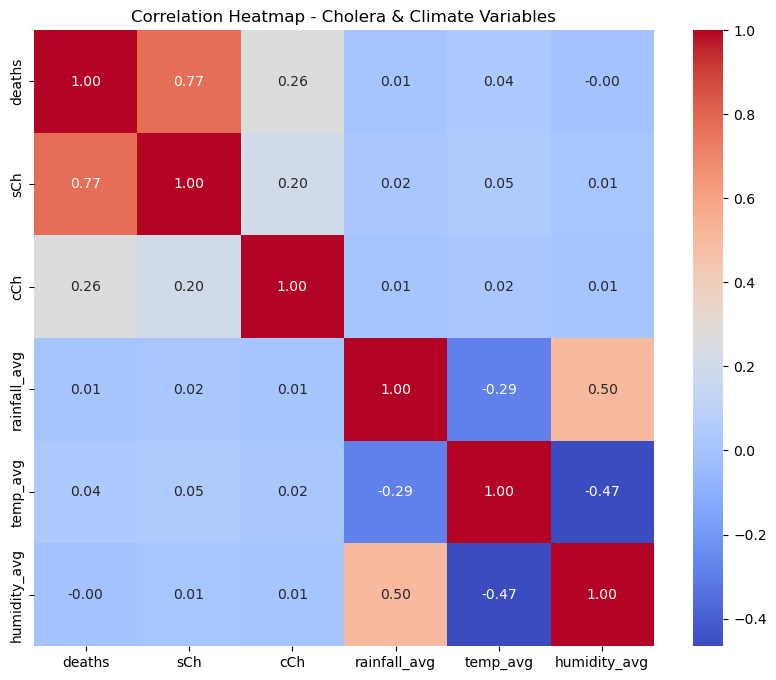

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("region_period_summary_0_5380.csv")

# Columns you want to analyze
cols = ["deaths", "sCh", "cCh", 
        "rainfall_avg", "temp_avg", "humidity_avg"]

# Convert to numeric (force errors to NaN)
df_numeric = df[cols].apply(pd.to_numeric, errors="coerce")

# Drop rows with NaN values
df_numeric = df_numeric.dropna()

# Compute correlation
corr_matrix = df_numeric.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap - Cholera & Climate Variables")
plt.show()

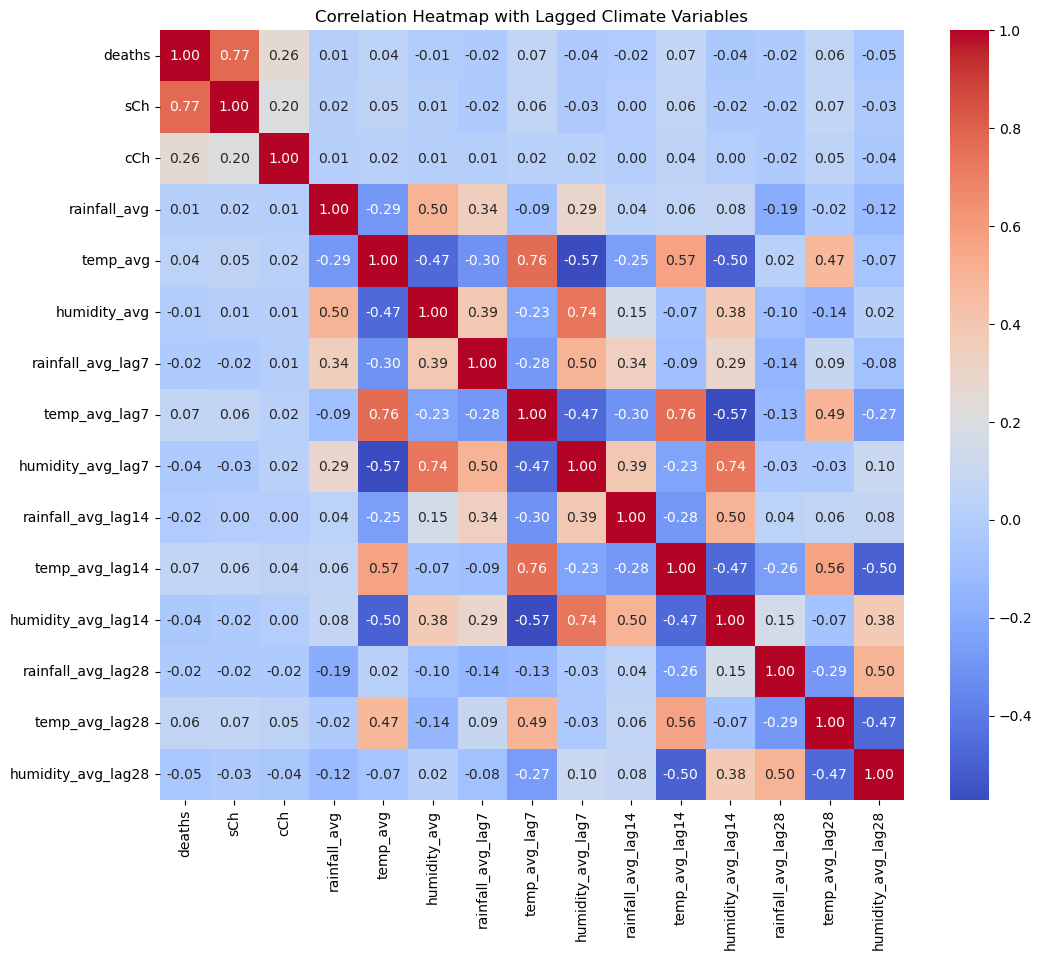

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("region_period_summary_0_5380.csv")

# Convert TL to datetime if it's a date column
df["TL"] = pd.to_datetime(df["TL"], errors="coerce")

# Example: create lagged versions of climate variables (1, 2, and 4 weeks)
for lag in [7, 14, 28]:  # days of lag
    df[f"rainfall_avg_lag{lag}"] = df["rainfall_avg"].shift(lag)
    df[f"temp_avg_lag{lag}"] = df["temp_avg"].shift(lag)
    df[f"humidity_avg_lag{lag}"] = df["humidity_avg"].shift(lag)

# Select numeric columns for correlation
numeric_cols = ["deaths","sCh","cCh",
                "rainfall_avg","temp_avg","humidity_avg",
                "rainfall_avg_lag7","temp_avg_lag7","humidity_avg_lag7",
                "rainfall_avg_lag14","temp_avg_lag14","humidity_avg_lag14",
                "rainfall_avg_lag28","temp_avg_lag28","humidity_avg_lag28"]

# Drop rows with NaN (caused by shifting)
df_numeric = df[numeric_cols].dropna()

# Compute correlation
corr_matrix = df_numeric.corr()

# Plot heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap with Lagged Climate Variables")
plt.show()

In [2]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Load dataset
df = pd.read_csv("region_period_summary_0_5380.csv")

# Drop missing values for relevant columns
df = df.dropna(subset=["sCh","cCh","deaths","rainfall_avg","temp_avg","humidity_avg"])

# Example: model suspected cholera cases (sCh) as a function of climate variables
poisson_model = smf.glm(
    formula="sCh ~ rainfall_avg + temp_avg + humidity_avg",
    data=df,
    family=sm.families.Poisson()
).fit()

print(poisson_model.summary())

# Predictions
df["predicted_sCh"] = poisson_model.predict(df)

# Accuracy metrics
mae = mean_absolute_error(df["sCh"], df["predicted_sCh"])
rmse = np.sqrt(mean_squared_error(df["sCh"], df["predicted_sCh"]))

print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)

                 Generalized Linear Model Regression Results                  
Dep. Variable:                    sCh   No. Observations:                 5379
Model:                            GLM   Df Residuals:                     5375
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -6.7006e+05
Date:                Sat, 25 Apr 2026   Deviance:                   1.3347e+06
Time:                        15:41:46   Pearson chi2:                 1.60e+07
No. Iterations:                    10   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -6.0220      0.041   -146.066   

In [3]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Load dataset
df = pd.read_csv("region_period_summary_0_5380.csv")

# Drop missing values for relevant columns
df = df.dropna(subset=["sCh","rainfall_avg","temp_avg","humidity_avg"])

# Fit Negative Binomial regression
nb_model = smf.glm(
    formula="sCh ~ rainfall_avg + temp_avg + humidity_avg",
    data=df,
    family=sm.families.NegativeBinomial()
).fit()

print(nb_model.summary())

# Predictions
df["predicted_sCh_nb"] = nb_model.predict(df)

# Accuracy metrics
mae_nb = mean_absolute_error(df["sCh"], df["predicted_sCh_nb"])
rmse_nb = np.sqrt(mean_squared_error(df["sCh"], df["predicted_sCh_nb"]))

print("Negative Binomial MAE:", mae_nb)
print("Negative Binomial RMSE:", rmse_nb)


                 Generalized Linear Model Regression Results                  
Dep. Variable:                    sCh   No. Observations:                 5379
Model:                            GLM   Df Residuals:                     5375
Model Family:        NegativeBinomial   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -22393.
Date:                Sat, 25 Apr 2026   Deviance:                       35735.
Time:                        15:45:29   Pearson chi2:                 5.48e+05
No. Iterations:                    39   Pseudo R-squ. (CS):             0.5783
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      -13.0455      0.202    -64.587   

C:\Users\Yangsi\anaconda3\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


In [4]:
import pandas as pd
import statsmodels.formula.api as smf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Load dataset
df = pd.read_csv("region_period_summary_0_5380.csv")

# Convert TL to datetime if needed
df["TL"] = pd.to_datetime(df["TL"], errors="coerce")

# Create lagged predictors (7, 14, 28 days)
for lag in [7, 14, 28]:
    df[f"rainfall_avg_lag{lag}"] = df["rainfall_avg"].shift(lag)
    df[f"temp_avg_lag{lag}"] = df["temp_avg"].shift(lag)
    df[f"humidity_avg_lag{lag}"] = df["humidity_avg"].shift(lag)

# Drop rows with NaN caused by shifting
df = df.dropna(subset=["sCh","rainfall_avg","temp_avg","humidity_avg",
                       "rainfall_avg_lag7","temp_avg_lag7","humidity_avg_lag7",
                       "rainfall_avg_lag14","temp_avg_lag14","humidity_avg_lag14",
                       "rainfall_avg_lag28","temp_avg_lag28","humidity_avg_lag28"])

# Fit Negative Binomial regression with lagged predictors
nb_model_lagged = smf.glm(
    formula=("sCh ~ rainfall_avg + temp_avg + humidity_avg "
             "+ rainfall_avg_lag7 + temp_avg_lag7 + humidity_avg_lag7 "
             "+ rainfall_avg_lag14 + temp_avg_lag14 + humidity_avg_lag14 "
             "+ rainfall_avg_lag28 + temp_avg_lag28 + humidity_avg_lag28"),
    data=df,
    family=sm.families.NegativeBinomial()
).fit()

print(nb_model_lagged.summary())

# Predictions
df["predicted_sCh_nb_lagged"] = nb_model_lagged.predict(df)

# Accuracy metrics
mae_nb_lagged = mean_absolute_error(df["sCh"], df["predicted_sCh_nb_lagged"])
rmse_nb_lagged = np.sqrt(mean_squared_error(df["sCh"], df["predicted_sCh_nb_lagged"]))

print("Negative Binomial with lags MAE:", mae_nb_lagged)
print("Negative Binomial with lags RMSE:", rmse_nb_lagged)

C:\Users\Yangsi\anaconda3\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                 Generalized Linear Model Regression Results                  
Dep. Variable:                    sCh   No. Observations:                 5351
Model:                            GLM   Df Residuals:                     5338
Model Family:        NegativeBinomial   Df Model:                           12
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -21477.
Date:                Sat, 25 Apr 2026   Deviance:                       33904.
Time:                        15:48:16   Pearson chi2:                 4.39e+05
No. Iterations:                   100   Pseudo R-squ. (CS):             0.6905
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept            -14.7426      0

In [9]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load dataset
df = pd.read_csv("region_period_summary_0_5380.csv")
df["TL"] = pd.to_datetime(df["TL"], errors="coerce")

# --- Feature Engineering ---

# Interaction terms
df["rain_temp"] = df["rainfall_avg"] * df["temp_avg"]
df["rain_humid"] = df["rainfall_avg"] * df["humidity_avg"]
df["temp_humid"] = df["temp_avg"] * df["humidity_avg"]

# Nonlinear terms
df["rainfall_sq"] = df["rainfall_avg"]**2
df["temp_sq"] = df["temp_avg"]**2
df["humidity_sq"] = df["humidity_avg"]**2

# Seasonal features
df["month"] = df["TL"].dt.month
df["is_rainy_season"] = df["month"].isin([5,6,7,8,9]).astype(int)

# Rolling averages (7‑day window)
df["rainfall_roll7"] = df["rainfall_avg"].rolling(7).mean()
df["temp_roll7"] = df["temp_avg"].rolling(7).mean()
df["humidity_roll7"] = df["humidity_avg"].rolling(7).mean()

# Drop rows with NaN from rolling window
df = df.dropna()

# --- Model Setup ---
formula = ("sCh ~ rainfall_avg + temp_avg + humidity_avg "
           "+ rain_temp + rain_humid + temp_humid "
           "+ rainfall_sq + temp_sq + humidity_sq "
           "+ is_rainy_season "
           "+ rainfall_roll7 + temp_roll7 + humidity_roll7")

# Fit Negative Binomial regression
nb_model_fe = smf.glm(
    formula=formula,
    data=df,
    family=sm.families.NegativeBinomial()
).fit()

print(nb_model_fe.summary())

# Predictions
df["predicted_sCh_fe"] = nb_model_fe.predict(df)

# Accuracy metrics
mae_fe = mean_absolute_error(df["sCh"], df["predicted_sCh_fe"])
rmse_fe = np.sqrt(mean_squared_error(df["sCh"], df["predicted_sCh_fe"]))

print("Feature‑engineered NB MAE:", mae_fe)
print("Feature‑engineered NB RMSE:", rmse_fe)


C:\Users\Yangsi\anaconda3\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                 Generalized Linear Model Regression Results                  
Dep. Variable:                    sCh   No. Observations:                 5373
Model:                            GLM   Df Residuals:                     5359
Model Family:        NegativeBinomial   Df Model:                           13
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -19979.
Date:                Sat, 25 Apr 2026   Deviance:                       30907.
Time:                        15:58:25   Pearson chi2:                 2.53e+05
No. Iterations:                   100   Pseudo R-squ. (CS):             0.8271
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept         -39.8053      2.427    -

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

# Load dataset
df = pd.read_csv("region_period_summary_0_5380.csv")
df["TL"] = pd.to_datetime(df["TL"], errors="coerce")

# --- Feature Engineering (same as before) ---
df["rain_temp"] = df["rainfall_avg"] * df["temp_avg"]
df["rain_humid"] = df["rainfall_avg"] * df["humidity_avg"]
df["temp_humid"] = df["temp_avg"] * df["humidity_avg"]

df["rainfall_sq"] = df["rainfall_avg"]**2
df["temp_sq"] = df["temp_avg"]**2
df["humidity_sq"] = df["humidity_avg"]**2

df["month"] = df["TL"].dt.month
df["is_rainy_season"] = df["month"].isin([5,6,7,8,9]).astype(int)

df["rainfall_roll7"] = df["rainfall_avg"].rolling(7).mean()
df["temp_roll7"] = df["temp_avg"].rolling(7).mean()
df["humidity_roll7"] = df["humidity_avg"].rolling(7).mean()

df = df.dropna()

# --- Handle categorical columns ---
# Example: if you have a 'region' column with values like 'North-West', 'South-West'
categorical_cols = df.select_dtypes(include=["object"]).columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# --- Features and Target ---
X = df.drop(columns=["sCh","TL"])   # predictors
y = df["sCh"]

# --- Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Random Forest Regressor
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)

# Accuracy metrics
mae_test = mean_absolute_error(y_test, y_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))

print("Train/Test Validation:")
print("Test MAE:", mae_test)
print("Test RMSE:", rmse_test)

# --- K-Fold Cross-Validation ---
kf = KFold(n_splits=5, shuffle=True, random_state=42)
mae_scores, rmse_scores = [], []

for train_index, val_index in kf.split(X):
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]
    
    model = RandomForestRegressor(n_estimators=200, random_state=42)
    model.fit(X_train, y_train)
    y_val_pred = model.predict(X_val)
    
    mae_scores.append(mean_absolute_error(y_val, y_val_pred))
    rmse_scores.append(np.sqrt(mean_squared_error(y_val, y_val_pred)))

print("\nK-Fold Cross-Validation:")
print("MAE scores:", mae_scores)
print("RMSE scores:", rmse_scores)
print("Average MAE:", np.mean(mae_scores))
print("Average RMSE:", np.mean(rmse_scores))


Train/Test Validation:
Test MAE: 27.817875310173694
Test RMSE: 235.6879548281373
